In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import mne

# so notebook can find src/
sys.path.append("..")

from src.fft_helpers_2 import load_subject, evaluate_subject, predict_fft, compute_fft, fft_scores, preprocess_trial, plot_fft_all_channels

from src.config import FS, STIM_ONSET, CH_NAMES, TARGET_FREQS

In [2]:
DATA_PATH = "../data/s1.mat"

eeg = load_subject(DATA_PATH)
print("EEG shape:", eeg.shape)

# 12 targets , 8 channels, 1114 time points, 15 trials

EEG shape: (12, 8, 1114, 15)


In [3]:
target_idx = 9
trial_idx = 10

trial = eeg[target_idx, :, :, trial_idx]
print("One raw trial shape:", trial.shape)

One raw trial shape: (8, 1114)


In [4]:
trial = eeg[target_idx, :, STIM_ONSET:, trial_idx]
print("After onset crop:", trial.shape)

trial_filt = preprocess_trial(trial, fs=FS)
print("Filtered trial shape:", trial_filt.shape)

After onset crop: (8, 1075)
Filtered trial shape: (8, 1075)


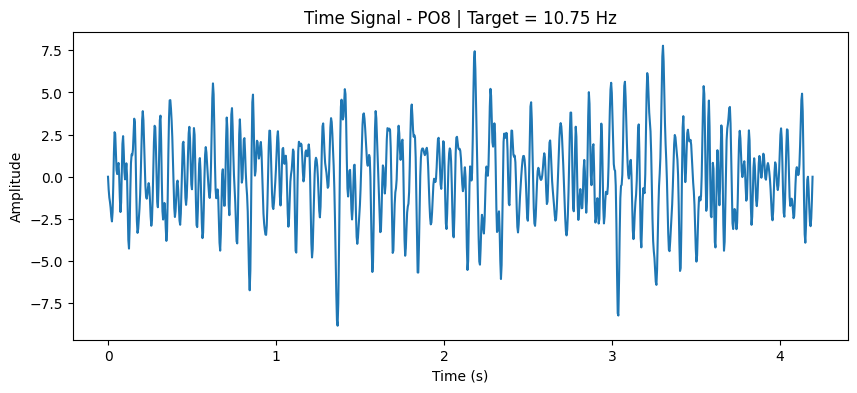

In [5]:
channel_idx = 4 # Oz
x = trial_filt[channel_idx]
t = np.arange(len(x)) / FS

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Time Signal - {CH_NAMES[channel_idx]} | Target = {TARGET_FREQS[target_idx]} Hz")
plt.show()

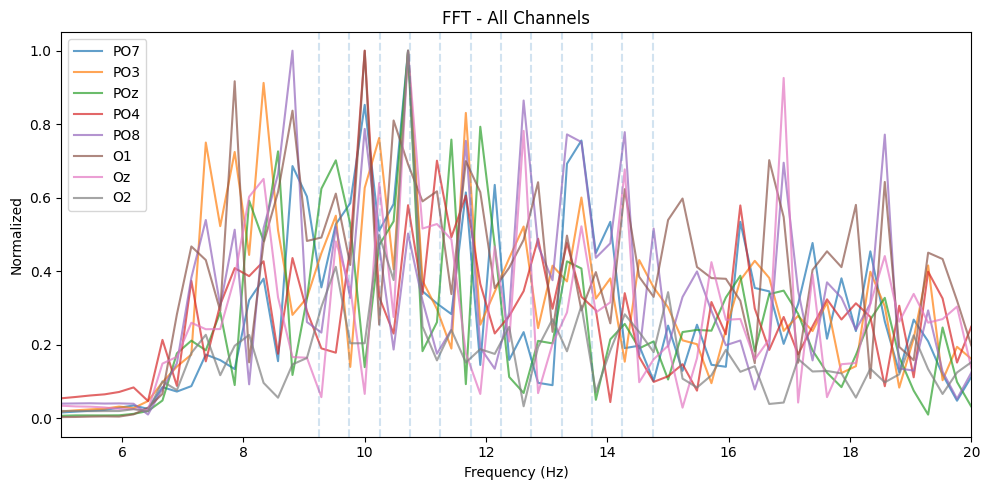

In [6]:
plot_fft_all_channels(
    trial_filt,
    fs=FS,
    ch_names=CH_NAMES,
    target_freq=None,
    target_freqs=TARGET_FREQS,
    normalize=True,
)

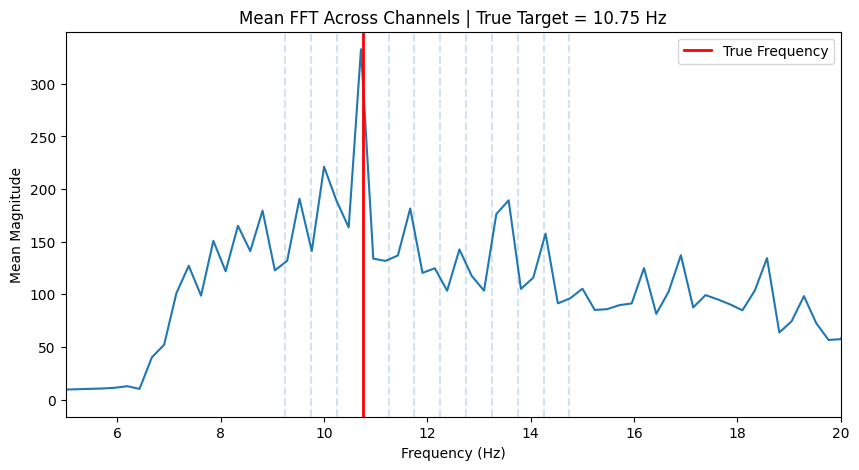

In [7]:
freqs, fft_vals = compute_fft(trial_filt, fs=FS)
mean_spectrum = fft_vals.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(freqs, mean_spectrum)
plt.xlim(5, 20)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean Magnitude")
plt.title(f"Mean FFT Across Channels | True Target = {TARGET_FREQS[target_idx]} Hz")

for f in TARGET_FREQS:
    plt.axvline(f, linestyle="--", alpha=0.2)

plt.axvline(TARGET_FREQS[target_idx], color="red", linewidth=2, label="True Frequency")
plt.legend()
plt.show()

In [8]:
scores = fft_scores(trial_filt, fs=FS)

for i, (f, s) in enumerate(zip(TARGET_FREQS, scores)):
    print(f"Class {i:2d} | Frequency {f:5.2f} Hz | Score = {s:.4f}")

Class  0 | Frequency  9.25 Hz | Score = 198.7235
Class  1 | Frequency 11.25 Hz | Score = 178.2770
Class  2 | Frequency 13.25 Hz | Score = 192.3288
Class  3 | Frequency  9.75 Hz | Score = 222.2847
Class  4 | Frequency 11.75 Hz | Score = 184.5609
Class  5 | Frequency 13.75 Hz | Score = 180.7530
Class  6 | Frequency 10.25 Hz | Score = 231.4727
Class  7 | Frequency 12.25 Hz | Score = 163.9013
Class  8 | Frequency 14.25 Hz | Score = 151.8727
Class  9 | Frequency 10.75 Hz | Score = 263.8239
Class 10 | Frequency 12.75 Hz | Score = 162.8677
Class 11 | Frequency 14.75 Hz | Score = 130.3465


In [9]:
pred_idx = predict_fft(trial_filt, fs=FS)

print("True target index:     ", target_idx)
print("True target frequency: ", TARGET_FREQS[target_idx], "Hz")
print("Predicted target index:", pred_idx)
print("Predicted frequency:   ", TARGET_FREQS[pred_idx], "Hz")

True target index:      9
True target frequency:  10.75 Hz
Predicted target index: 9
Predicted frequency:    10.75 Hz


In [10]:
acc = evaluate_subject(eeg)
print(f"Subject accuracy: {acc:.4f} ({acc*100:.2f}%)")

Subject accuracy: 0.4556 (45.56%)


In [11]:


n_targets = eeg.shape[0]
n_trials = eeg.shape[3]

per_target_acc = []

for true_target in range(n_targets):
    correct = 0
    
    for trial_idx in range(n_trials):
        trial = eeg[true_target, :, STIM_ONSET:, trial_idx]
        trial_filt = preprocess_trial(trial, fs=FS)
        pred = predict_fft(trial_filt, fs=FS)
        
        if pred == true_target:
            correct += 1
    
    acc_target = correct / n_trials
    per_target_acc.append(acc_target)

for i, acc_target in enumerate(per_target_acc):
    print(f"Target {i:2d} | Frequency {TARGET_FREQS[i]:5.2f} Hz | Accuracy = {acc_target:.4f}")

Target  0 | Frequency  9.25 Hz | Accuracy = 0.9333
Target  1 | Frequency 11.25 Hz | Accuracy = 0.4000
Target  2 | Frequency 13.25 Hz | Accuracy = 0.1333
Target  3 | Frequency  9.75 Hz | Accuracy = 1.0000
Target  4 | Frequency 11.75 Hz | Accuracy = 0.4000
Target  5 | Frequency 13.75 Hz | Accuracy = 0.2667
Target  6 | Frequency 10.25 Hz | Accuracy = 1.0000
Target  7 | Frequency 12.25 Hz | Accuracy = 0.0667
Target  8 | Frequency 14.25 Hz | Accuracy = 0.2667
Target  9 | Frequency 10.75 Hz | Accuracy = 0.6667
Target 10 | Frequency 12.75 Hz | Accuracy = 0.0000
Target 11 | Frequency 14.75 Hz | Accuracy = 0.3333


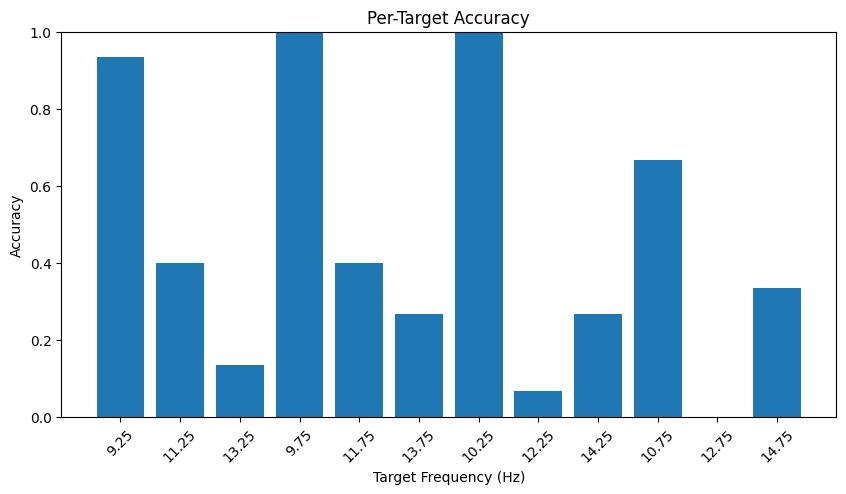

In [12]:
plt.figure(figsize=(10, 5))
plt.bar([str(f) for f in TARGET_FREQS], per_target_acc)
plt.xlabel("Target Frequency (Hz)")
plt.ylabel("Accuracy")
plt.title("Per-Target Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.show()

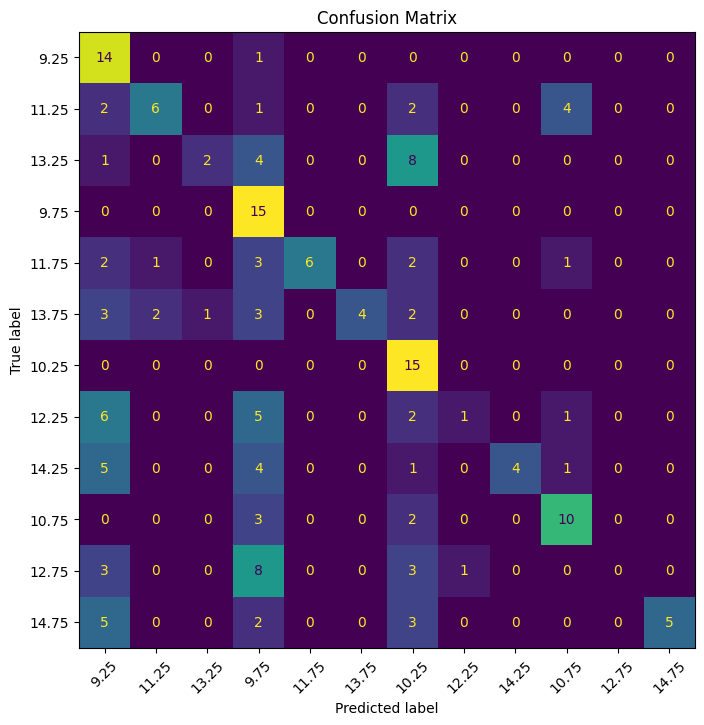

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for true_target in range(n_targets):
    for trial_idx in range(n_trials):
        trial = eeg[true_target, :, STIM_ONSET:, trial_idx]
        trial_filt = preprocess_trial(trial, fs=FS)
        pred = predict_fft(trial_filt, fs=FS)

        y_true.append(true_target)
        y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred, labels=list(range(n_targets)))

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{f:.2f}" for f in TARGET_FREQS])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.show()